<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/06_pytorch_transfer_learning_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch Transfer Learning Exercises

Welcome to the 06. PyTorch Transfer Learning exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 06. PyTorch Transfer Learning](https://www.learnpytorch.io/06_pytorch_transfer_learning/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:**

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ueLolShyFqs).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/06_pytorch_transfer_learning_exercise_solutions.ipynb).

## 1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels.
* **Note:** You will need to get the dataset and the trained model/retrain the model from notebook 06 to perform predictions.
* Check out [03. PyTorch Computer Vision section 10](https://www.learnpytorch.io/03_pytorch_computer_vision/#10-making-a-confusion-matrix-for-further-prediction-evaluation) for ideas.

In [ ]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms, datasets

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 35.14 MiB/s, done.
Resolving deltas: 100% (2657/2657), done.
Updating files: 100% (248/248), done.


In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

I put in the CPU because then it has limits on usage, and I wouldn't want it to disconnect mid-session

### Get data

In [ ]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


### Prepare data

In [ ]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [ ]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b8b877abe50>,
 ['pizza', 'steak', 'sushi'])

### Get and prepare a pretrained model

In [ ]:
# Setup the model with pretrained weights and send it to the target device
model_0 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
#model_0 # uncomment to output (it's very long)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 93.2MB/s]


In [ ]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [ ]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### Train model

In [ ]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

In [ ]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
model_0_results = engine.train(model=model_0,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1033 | train_acc: 0.3789 | test_loss: 0.8906 | test_acc: 0.5701
Epoch: 2 | train_loss: 0.9392 | train_acc: 0.6445 | test_loss: 0.8079 | test_acc: 0.7027
Epoch: 3 | train_loss: 0.7611 | train_acc: 0.8945 | test_loss: 0.6431 | test_acc: 0.9072
Epoch: 4 | train_loss: 0.7602 | train_acc: 0.6992 | test_loss: 0.5840 | test_acc: 0.8968
Epoch: 5 | train_loss: 0.6309 | train_acc: 0.8867 | test_loss: 0.6012 | test_acc: 0.9072
[INFO] Total training time: 171.678 seconds


### Make predictions on the entire test dataset with the model

In [ ]:
# From ChatGPT, it makes more sense this way to retrieve the images easily and plot them later.
from torchvision.datasets import ImageFolder
from PIL import Image

class ImageFolderWithPaths(ImageFolder):
    def __getitem__(self, index):
        # this is the standard tuple (image_tensor, class_index)
        original_tuple = super().__getitem__(index)

        # get the path to the image file
        path = self.imgs[index][0]

        # return (image, label, path)
        return original_tuple + (path,)

In [ ]:
from torch.utils.data import DataLoader
import os

test_folder_imgs = ImageFolderWithPaths(
    root=test_dir,
    transform=simple_transform,
    target_transform=None
)
test_dataloader = DataLoader(
    dataset=test_folder_imgs,
    batch_size=32,
    shuffle=False,
    num_workers=os.cpu_count(),
    pin_memory=True
)

In [ ]:
# TODO
model_0.eval()
y_preds_accumulate = []

y_incorrect_pred_labels = []
y_incorrect_truth = []
y_incorrect_pred_probs = []
y_incorrect_img_paths = []

with torch.inference_mode():
  for index, (X, y, img_path) in enumerate(test_dataloader): #For each batch
    print(len(y))
    X, y = X.to(device), y.to(device)
    y_batch_logits = model_0(X)
    y_batch_pred_probs = torch.softmax(y_batch_logits, dim=1)
    y_batch_highest_preds, y_batch_preds = torch.max(y_batch_pred_probs, dim=1)
    #print(y_batch_preds, y_preds)
    #print(y_batch_preds.ndim, y_batch_preds.shape, y_batch_preds.squeeze().ndim)
    y_preds_accumulate.append(y_batch_preds.cpu())
    #print(y.shape, X.shape)
    y_correct_prob = torch.gather(y_batch_pred_probs, dim=1, index=y.unsqueeze(dim=1))
    #print(y_correct_prob)

    # Check for any mistakes in this batch
    # Asked ChatGPT how to get a Logic Matrix AND how to use it to obtain items.
    y_incorrect_logic_matrix = (y != y_batch_preds)
    # If so, then let's get the predictions, the probs, and the image path.
    if y_incorrect_logic_matrix.any():

      # What was predicted?
      y_inc_pred_labels = y_batch_preds[y_incorrect_logic_matrix]
      y_incorrect_pred_labels.extend(y_inc_pred_labels)

      # What was the truth?
      y_inc_truth = y[y_incorrect_logic_matrix]
      y_incorrect_truth.extend(y_inc_truth)

      # What was the prediction probability?
      y_inc_pred_probs = y_batch_highest_preds[y_incorrect_logic_matrix]
      y_incorrect_pred_probs.extend(y_inc_pred_probs)

      # What is the image path?
      #from ChatGPT
      y_incorrect_images = [path for path, condition in zip(img_path, y_incorrect_logic_matrix) if condition]
      y_incorrect_img_paths.extend(y_incorrect_images)


#y_preds_accumulate
#y_pred_tensor = torch.cat(y_preds_accumulate).unsqueeze(dim=0)
#y_pred_tensor, type(y_pred_tensor), y_pred_tensor.shape

32
32
11


In [ ]:
len(y_incorrect_pred_labels), len(y_incorrect_truth), len(y_incorrect_pred_probs), len(y_incorrect_img_paths)

(7, 7, 7, 7)

In [ ]:
y_pred_tensor = torch.cat(y_preds_accumulate)
y_pred_tensor.shape, y_pred_tensor

(torch.Size([75]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2,
         2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
         2, 2, 2]))

### Make a confusion matrix with the test preds and the truth labels

Need the following libraries to make a confusion matrix:
* torchmetrics - https://torchmetrics.readthedocs.io/en/stable/
* mlxtend - http://rasbt.github.io/mlxtend/

In [ ]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 998.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.0 MB/s eta 0:00:00
mlxtend version: 0.23.4


In [ ]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
from torchvision import datasets

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
        2, 2, 2])
<class 'torch.Tensor'> torch.Size([75])
<class 'list'>
<class 'torch.Tensor'> torch.Size([1, 75])


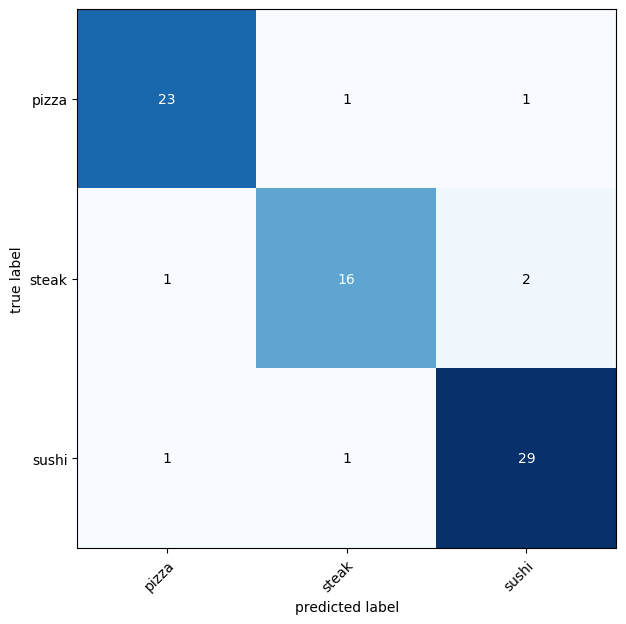

In [ ]:
confmat = ConfusionMatrix(
    num_classes=len(class_names),
    task="multiclass"
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform #You can also jut not specify the target_transform
)
print(y_pred_tensor)
print(type(y_pred_tensor), y_pred_tensor.shape)
print(type(test_data.targets))
target_tensor = torch.tensor(test_data.targets).unsqueeze(dim=0)
print(type(target_tensor), target_tensor.shape)
confmat_tensor = confmat(
    preds=y_pred_tensor.unsqueeze(dim=0),
    target=target_tensor
)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), #matplotlib underneath, which likes working w/ NumPy
    class_names = class_names,
    figsize=(10, 7)
)

## 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

In [ ]:
y_incorrect_pred_labels

[tensor(1), tensor(2), tensor(2), tensor(2), tensor(0), tensor(0), tensor(1)]

In [ ]:
# TODO
import pandas as pd

predictions_df = pd.DataFrame({
    "prediction":[t.item() for t in y_incorrect_pred_labels],
    "truth":[t.item() for t in y_incorrect_truth],
    "prob":[t.item() for t in y_incorrect_pred_probs],
    "img_path":y_incorrect_img_paths
})
predictions_df

,prediction,truth,prob,img_path
0,1,0,0.420366,data/pizza_steak_sushi/test/pizza/2508636.jpg
1,2,0,0.366920,data/pizza_steak_sushi/test/pizza/2871261.jpg
2,2,1,0.424436,data/pizza_steak_sushi/test/steak/1285886.jpg
3,2,1,0.388568,data/pizza_steak_sushi/test/steak/1627703.jpg
4,0,1,0.364794,data/pizza_steak_sushi/test/steak/3873283.jpg
5,0,2,0.390239,data/pizza_steak_sushi/test/sushi/175783.jpg
6,1,2,0.504829,data/pizza_steak_sushi/test/sushi/684266.jpg


In [ ]:
wrong_preds_desc = predictions_df.sort_values(by="prob", ascending=False)

In [ ]:
wrong_preds_desc

,prediction,truth,prob,img_path
6,1,2,0.504829,data/pizza_steak_sushi/test/sushi/684266.jpg
2,2,1,0.424436,data/pizza_steak_sushi/test/steak/1285886.jpg
0,1,0,0.420366,data/pizza_steak_sushi/test/pizza/2508636.jpg
5,0,2,0.390239,data/pizza_steak_sushi/test/sushi/175783.jpg
3,2,1,0.388568,data/pizza_steak_sushi/test/steak/1627703.jpg
1,2,0,0.366920,data/pizza_steak_sushi/test/pizza/2871261.jpg
4,0,1,0.364794,data/pizza_steak_sushi/test/steak/3873283.jpg


<Figure size 640x480 with 0 Axes>

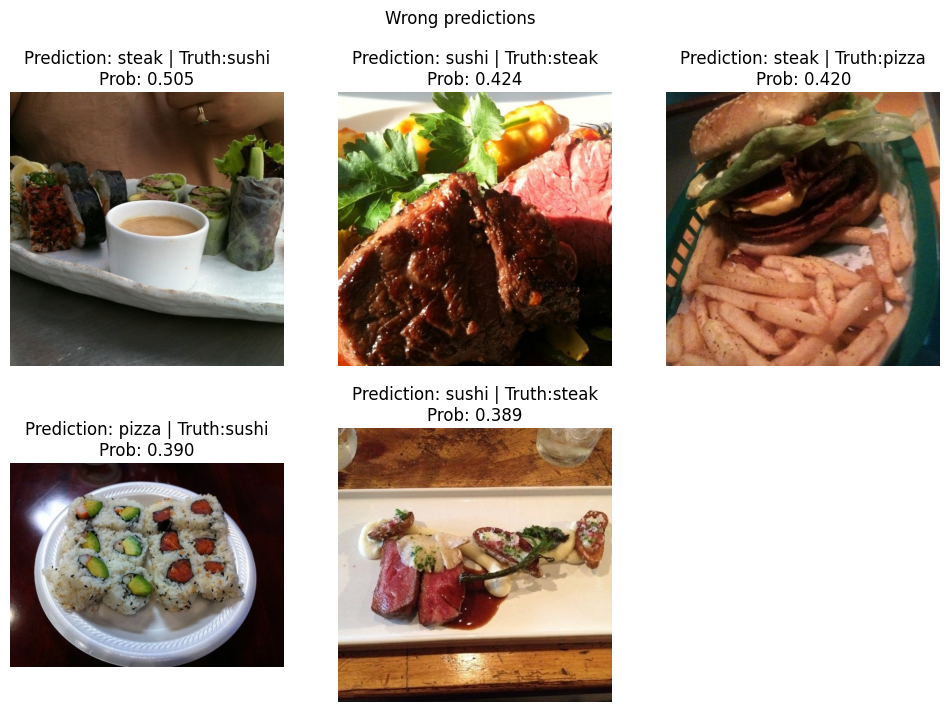

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

nrows = 2
ncols = 3
plt.tight_layout()
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8))
fig.suptitle("Wrong predictions")
number_of_plots = 5
# Had help from ChatGPT to know how to iterate over items in Pandas (iterrows())
for idx, (index, row) in enumerate(wrong_preds_desc.iloc[:number_of_plots].iterrows()):

  # Used ChatGPT for this automatic setting of images, I had done it once so
  # I knew the trick was something like this, but I asked how it was done again.
  col_idx = idx % ncols
  row_idx = idx // ncols

  ax = axes[row_idx][col_idx]
  ax.axis("off")

  img_path = row["img_path"]
  image = Image.open(img_path)

  ax.imshow(image)
  pred = class_names[row["prediction"]]
  prob = float(row["prob"])
  truth = class_names[ row["truth"] ]
  ax.set_title(f"Prediction: { pred } | Truth:{truth}\nProb: { prob:.3f}", fontsize=12) # NEVER add a space like so `.3f }`, it should be `.3f}`

# Turn off the unused subplot - ChatGPT
if number_of_plots < (nrows*ncols):
    for idx in range(number_of_plots, (nrows*ncols)):
        col_idx = idx % ncols
        row_idx = idx // ncols
        axes[row_idx][col_idx].axis("off")

## 3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?
* Here you can get an image from a website like http://www.unsplash.com to try it out or you can upload your own.

In [ ]:
import requests
import torchvision
import matplotlib.pyplot as plt

def get_image(your_file_name : str, url : str):
  img_path = data_path / your_file_name
  if not img_path.is_file():
    with open(img_path, "wb") as f:
      req = requests.get(url)
      print(f"Downloading '{img_path}'")
      f.write(req.content)
  else:
    print(f"Image '{img_path}' already downloaded")
  return img_path

In [ ]:
# TODO: Get an image of pizza/steak/sushi
my_img_url = "https://images.unsplash.com/photo-1600891964092-4316c288032e?q=80&w=2070&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

my_img_path = get_image("my_img.jped", my_img_url)
my_img_uint8 = torchvision.io.read_image(
    path=my_img_path
)
my_img_float32 = my_img_uint8.type(torch.float32) / 255.
print(type(my_img_uint8), my_img_uint8.dtype, my_img_uint8.shape)

Image 'data/my_img.jped' already downloaded
<class 'torch.Tensor'> torch.uint8 torch.Size([3, 1380, 2070])


(np.float64(-0.5), np.float64(2069.5), np.float64(1379.5), np.float64(-0.5))

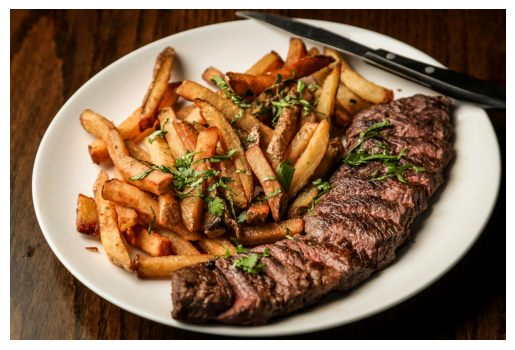

In [ ]:
plt.imshow(my_img_uint8.permute(1, 2, 0))
plt.axis(False)

In [ ]:
pred_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])
pred_transform2 = transforms.Compose([
    transforms.Resize((224, 224)) #What if I have a simpler transform without the normalization?
])

In [ ]:
def plot_transforms(your_image_tensor):
  img_tf_1 = pred_transform(your_image_tensor)
  img_tf_2 = pred_transform2(your_image_tensor)
  nrows = 1
  ncols = 2
  plt.tight_layout()
  fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 4))

  ax = axes[0]
  ax.axis("off")

  ax.imshow(img_tf_1.permute(1, 2, 0))
  ax.set_title(f"Normalized Transform")

  ax = axes[1]
  ax.axis("off")

  ax.imshow(img_tf_2.permute(1, 2, 0))
  ax.set_title(f"Resize-Only Transform");

<Figure size 640x480 with 0 Axes>

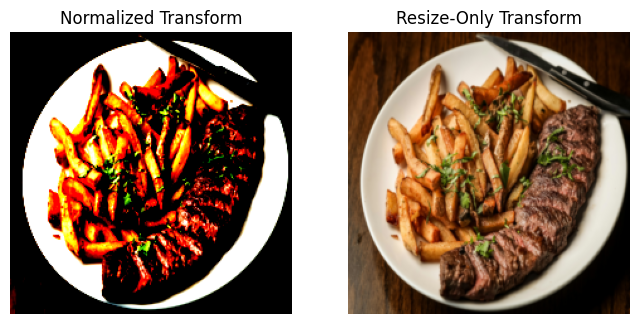

In [ ]:
plot_transforms(my_img_float32)

In [ ]:
# TODO: Get an image of not pizza/steak/sushi
tucson_url = "https://images.unsplash.com/photo-1698273191536-0577ff2b94cc?q=80&w=3132&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

tucson_img_path = get_image("tucson_img.jpeg", tucson_url)
tucson_img_uint8 = torchvision.io.read_image(
    path=tucson_img_path
)
tucson_img_float32 = tucson_img_uint8.type(torch.float32) / 255.
print(type(tucson_img_uint8), tucson_img_uint8.dtype, tucson_img_float32.shape)

Image 'data/tucson_img.jpeg' already downloaded
<class 'torch.Tensor'> torch.uint8 torch.Size([3, 1760, 3132])


<Figure size 640x480 with 0 Axes>

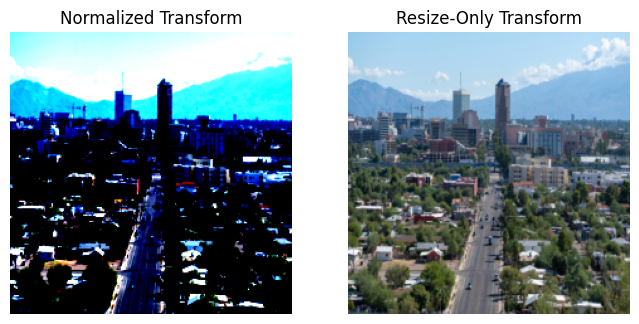

In [ ]:
plot_transforms(tucson_img_float32)

Now let's do the predictions

In [ ]:
def predict_and_plot(your_img_tensor):
  model_0.eval()
  with torch.inference_mode():

    y_logits = model_0(your_img_tensor.unsqueeze(dim=0).to(device))
    y_pred_probs = torch.softmax(y_logits, dim=1)
    print(y_pred_probs)
    y_preds = torch.argmax(y_pred_probs, dim=1).item()

    plt.imshow(your_img_tensor.permute(1, 2, 0))
    plt.axis(False)
    probs = y_pred_probs.squeeze()[y_preds]
    label = class_names[y_preds]
    plt.title(f"Pred: {label} | Prob: {probs:.3f}")

tensor([[0.4450, 0.2926, 0.2625]])


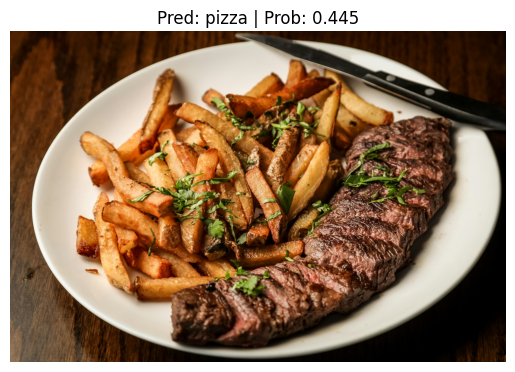

In [ ]:
predict_and_plot(my_img_float32)

tensor([[0.3519, 0.3641, 0.2840]])


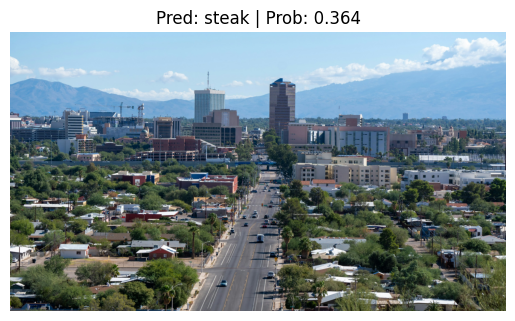

In [ ]:
predict_and_plot(tucson_img_float32)

## 4. Train the model from section 4  in notebook 06 part 3 for longer (10 epochs should do), what happens to the performance?

* See the model in notebook 06 part 3 for reference: https://www.learnpytorch.io/06_pytorch_transfer_learning/#3-getting-a-pretrained-model

In [ ]:
# Getting `torchinfo`
try:
  from torchinfo import summary
except:
  print("[INFO] Couldn't find torchinfo... installing...")
  !pip install -q torchinfo
  from torchinfo import summary

In [ ]:
# TODO: Recreate a new model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT = best available weights
model_pretrained = torchvision.models.efficientnet_b0(weights=weights).to(device)
auto_transforms = weights.transforms()


In [ ]:
summary(model_pretrained)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

In [ ]:
model_pretrained.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
model_pretrained.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=3, bias=True)
)

In [ ]:
optimizer = torch.optim.Adam(
    params=model_pretrained.parameters(),
    lr=0.001
)
loss_fn = nn.CrossEntropyLoss()

for param in model_pretrained.features.parameters():
  #print(param)
  param.requires_grad = False

In [ ]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b8b86ee7410>,
 ['pizza', 'steak', 'sushi'])

In [ ]:
# TODO: Train the model for 10 epochs
model_pretrained_results = engine.train(
    model=model_pretrained,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer = optimizer,
    loss_fn = loss_fn,
    epochs=10,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8636 | train_acc: 0.8047 | test_loss: 0.8292 | test_acc: 0.7424
Epoch: 2 | train_loss: 0.7761 | train_acc: 0.7305 | test_loss: 0.7773 | test_acc: 0.7216
Epoch: 3 | train_loss: 0.7161 | train_acc: 0.7383 | test_loss: 0.7008 | test_acc: 0.8144
Epoch: 4 | train_loss: 0.6183 | train_acc: 0.8945 | test_loss: 0.6020 | test_acc: 0.8561
Epoch: 5 | train_loss: 0.6085 | train_acc: 0.7773 | test_loss: 0.5761 | test_acc: 0.9072
Epoch: 6 | train_loss: 0.5394 | train_acc: 0.9219 | test_loss: 0.5015 | test_acc: 0.8968
Epoch: 7 | train_loss: 0.4830 | train_acc: 0.8828 | test_loss: 0.4693 | test_acc: 0.8759
Epoch: 8 | train_loss: 0.5539 | train_acc: 0.7461 | test_loss: 0.4424 | test_acc: 0.8968
Epoch: 9 | train_loss: 0.5273 | train_acc: 0.8086 | test_loss: 0.4713 | test_acc: 0.8655
Epoch: 10 | train_loss: 0.4429 | train_acc: 0.9414 | test_loss: 0.5024 | test_acc: 0.9176


## 5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


### Get 20% data

In [ ]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"
image_data_zip_path = "pizza_steak_sushi_20_percent.zip"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / image_data_zip_path, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / image_data_zip_path, "r") as zip_ref:
        print("Unzipping pizza, steak, sushi 20% data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / image_data_zip_path)

# Setup Dirs
train_dir_20_percent = image_path / "train"
test_dir_20_percent = image_path / "test"

train_dir_20_percent, test_dir_20_percent

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

### Create DataLoaders

In [ ]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [ ]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader_20_percent, test_dataloader_20_percent, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                                     test_dir=test_dir_20_percent,
                                                                                                     transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                                     batch_size=32) # set mini-batch size to 32

train_dataloader_20_percent, test_dataloader_20_percent, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b8b878e25d0>,
 ['pizza', 'steak', 'sushi'])

### Get a pretrained model

In [ ]:
# TODO
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
weights = EfficientNet_B0_Weights.DEFAULT
model_pretrained_2 = efficientnet_b0(weights=weights).to(device)

In [ ]:
model_pretrained_2.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
model_pretrained_2.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
)
model_pretrained_2.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

In [ ]:
for param in model_pretrained_2.features.parameters():
  #print(param)
  param.requires_grad = False

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_pretrained_2.parameters(),
    lr=0.001
)

### Train a model with 20% of the data

In [ ]:
# TODO
model_pretrained_2_results = engine.train(
    model=model_pretrained_2,
    train_dataloader=train_dataloader_20_percent,
    test_dataloader=test_dataloader_20_percent,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9655 | train_acc: 0.6021 | test_loss: 0.6516 | test_acc: 0.8523
Epoch: 2 | train_loss: 0.7385 | train_acc: 0.7312 | test_loss: 0.5207 | test_acc: 0.8818
Epoch: 3 | train_loss: 0.5745 | train_acc: 0.8792 | test_loss: 0.4756 | test_acc: 0.9131
Epoch: 4 | train_loss: 0.4708 | train_acc: 0.8875 | test_loss: 0.4086 | test_acc: 0.9068
Epoch: 5 | train_loss: 0.4418 | train_acc: 0.8917 | test_loss: 0.3794 | test_acc: 0.9222
Epoch: 6 | train_loss: 0.3998 | train_acc: 0.9042 | test_loss: 0.3332 | test_acc: 0.9068
Epoch: 7 | train_loss: 0.4083 | train_acc: 0.8771 | test_loss: 0.3225 | test_acc: 0.9068
Epoch: 8 | train_loss: 0.4500 | train_acc: 0.8250 | test_loss: 0.3268 | test_acc: 0.9131
Epoch: 9 | train_loss: 0.3264 | train_acc: 0.9083 | test_loss: 0.2993 | test_acc: 0.9222
Epoch: 10 | train_loss: 0.3138 | train_acc: 0.9208 | test_loss: 0.2790 | test_acc: 0.9352


## 6. Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [ ]:
# TODO
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
weights_mb = MobileNet_V3_Small_Weights.DEFAULT
mobilenet_model = mobilenet_v3_small(weights=weights_mb).to(device)
auto_transforms_mb = weights_mb.transforms()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 83.3MB/s]


In [ ]:
mobilenet_model.classifier

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)

In [ ]:
mobilenet_model.classifier = nn.Sequential(
    nn.Linear(in_features=576, out_features=1024, bias=True),
    nn.Hardswish(),
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1024, out_features=3, bias=True)
)
mobilenet_model.classifier

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=3, bias=True)
)

In [ ]:
optimizer_mbnet = torch.optim.Adam(
    params=mobilenet_model.parameters(),
    lr=0.001
)
loss_fn_mbnet = nn.CrossEntropyLoss()

mobilenet_results = engine.train(
    model=mobilenet_model,
    train_dataloader=train_dataloader_20_percent,
    test_dataloader=test_dataloader_20_percent,
    optimizer=optimizer_mbnet,
    loss_fn=loss_fn_mbnet,
    epochs=10,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6756 | train_acc: 0.7229 | test_loss: 0.4431 | test_acc: 0.8455
Epoch: 2 | train_loss: 0.5268 | train_acc: 0.9062 | test_loss: 0.3450 | test_acc: 0.8938
Epoch: 3 | train_loss: 0.1947 | train_acc: 0.9333 | test_loss: 0.6247 | test_acc: 0.8187
Epoch: 4 | train_loss: 0.2259 | train_acc: 0.9146 | test_loss: 0.2802 | test_acc: 0.9313
Epoch: 5 | train_loss: 0.3707 | train_acc: 0.9437 | test_loss: 0.2286 | test_acc: 0.9097
Epoch: 6 | train_loss: 0.1390 | train_acc: 0.9437 | test_loss: 0.1990 | test_acc: 0.9347
Epoch: 7 | train_loss: 0.3847 | train_acc: 0.9083 | test_loss: 0.6927 | test_acc: 0.8597
Epoch: 8 | train_loss: 0.2694 | train_acc: 0.8938 | test_loss: 0.5579 | test_acc: 0.8472
Epoch: 9 | train_loss: 0.0934 | train_acc: 0.9771 | test_loss: 0.2377 | test_acc: 0.9500
Epoch: 10 | train_loss: 0.0844 | train_acc: 0.9563 | test_loss: 0.4358 | test_acc: 0.9062


In [ ]:
def predict_and_plot_mbnet(your_img_tensor):
  mobilenet_model.eval()
  with torch.inference_mode():

    y_logits = mobilenet_model(your_img_tensor.unsqueeze(dim=0).to(device))
    y_pred_probs = torch.softmax(y_logits, dim=1)
    print(y_pred_probs)
    y_preds = torch.argmax(y_pred_probs, dim=1).item()

    plt.imshow(your_img_tensor.permute(1, 2, 0))
    plt.axis(False)
    probs = y_pred_probs.squeeze()[y_preds]
    label = class_names[y_preds]
    plt.title(f"Pred: {label} | Prob: {probs:.3f}")

In [ ]:
my_img_mbtf = auto_transforms_mb(my_img_float32)
my_img_mbtf.shape

torch.Size([3, 224, 224])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

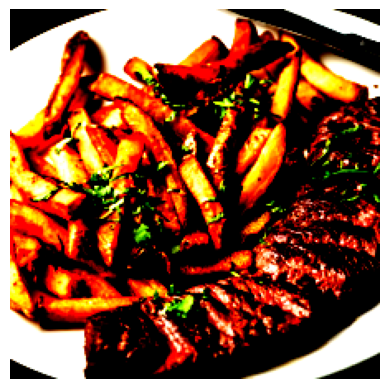

In [ ]:
plt.imshow(my_img_mbtf.permute(1, 2, 0))
plt.axis(False)

tensor([[1.7496e-05, 9.9101e-01, 8.9714e-03]])


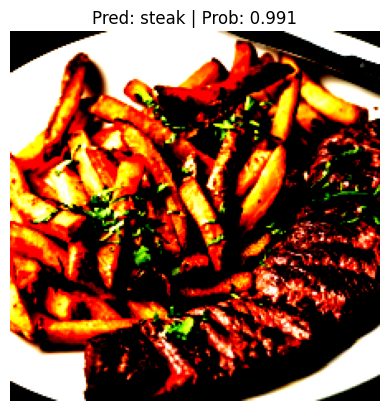

In [ ]:
predict_and_plot_mbnet(my_img_mbtf)

tensor([[9.4308e-04, 1.5456e-02, 9.8360e-01]])


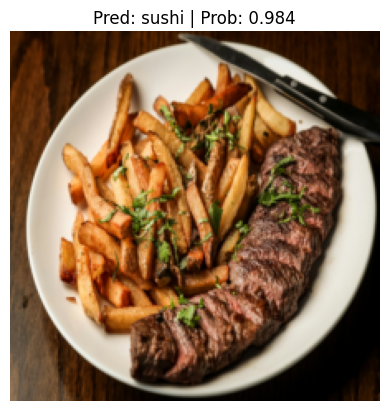

In [ ]:
my_img_mbtf2 = transforms.Compose([
    transforms.Resize((224, 224))
])(my_img_float32)
predict_and_plot_mbnet(my_img_mbtf2)

In [ ]:
tucson_img_mbtf = auto_transforms_mb(tucson_img_float32)
tucson_img_mbtf.shape

torch.Size([3, 224, 224])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

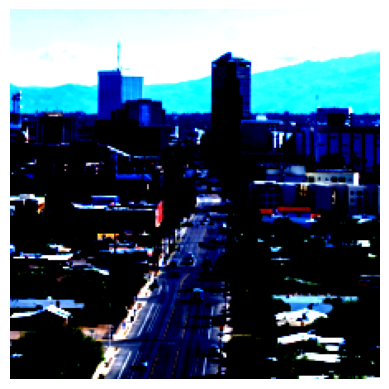

In [ ]:
plt.imshow(tucson_img_mbtf.permute(1, 2, 0))
plt.axis(False)

tensor([[1.1656e-06, 3.9145e-07, 1.0000e+00]])


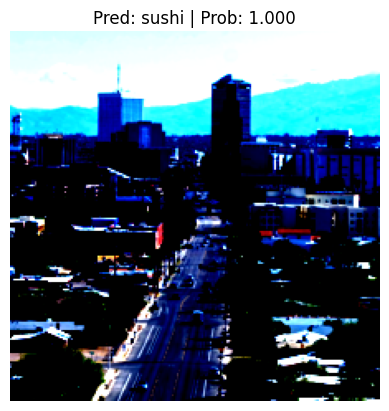

In [ ]:
predict_and_plot_mbnet(tucson_img_mbtf)

# Metadata Cleaning

In [ ]:
import nbformat

notebook_path = '/content/drive/MyDrive/Colab Notebooks/06_pytorch_transfer_learning_exercises.ipynb'  # Update as needed

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']
    print("Removed 'widgets' metadata.")
else:
    print("No 'widgets' metadata found.")

with open(notebook_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)
    print("Notebook cleaned and saved back to Drive.")